# HEATWARD — Model 2 pipeline (Colab)

**Ward-level heat-health risk for Kolkata.** SIH PS 26083, MoES / NCMRWF.

This notebook replaces the synthetic-weather pipeline. Run the cells in order; each
section ends in a **gate** — a printed check you must read before continuing. If a gate
fails, stop and fix it rather than pushing on.

### What is real and what is not

| Layer | Provenance | Why |
|---|---|---|
| Weather (T, RH, wind, radiation) | **REAL** — ERA5 via Open-Meteo | Free, no API key, hourly, 1940→now |
| Thermal indices (HI, WBGT, UTCI) | **COMPUTED** from real weather | Standard published formulas |
| Ward geometry | *placeholder centroids* | Swap in the KMC 144-ward file when you have it |
| Demographics | *synthetic, Census-shaped* | Census 2011 ward tables need manual extraction |
| Reported heatstroke deaths | **ANCHORED** to real NCRB state totals | See §5 — this is the important trick |
| Excess all-cause mortality | **TRANSFERRED** from published curve | No ward-level ground truth exists in India |

The only fully invented layer is ward demographics. Everything else is either real,
computed from real inputs, or anchored to a real published total.

### Runtime
Runtime → Change runtime type → **CPU** is fine. No GPU needed.

In [ ]:
#@title Install dependencies { display-mode: "form" }
!pip install -q pythermalcomfort requests
print("done")

done


In [ ]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*datetime.datetime.utcnow.*", category=DeprecationWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})

SEED = 42
rng  = np.random.default_rng(SEED)

# ---- config -------------------------------------------------------------
CITY        = "Kolkata"
CITY_LATLON = (22.5726, 88.3639)
START, END  = "2019-01-01", "2025-12-31"

# Split by YEAR, so every partition contains a full April-June heat season.
TEST_YEARS  = (2025,)
VAL_YEARS   = (2024,)

CACHE = Path("/content/heatward_cache"); CACHE.mkdir(exist_ok=True, parents=True)
print(f"{CITY} | {START} to {END} | cache -> {CACHE}")

Kolkata | 2019-01-01 to 2025-12-31 | cache -> /content/heatward_cache


In [ ]:
#@title Optional: mount Drive so the fetched data survives a runtime reset
USE_DRIVE = True  #@param {type:"boolean"}
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    CACHE = Path("/content/drive/MyDrive/heatward_cache"); CACHE.mkdir(exist_ok=True, parents=True)
    print("cache ->", CACHE)
else:
    print("Using ephemeral /content cache. Set USE_DRIVE=True to persist across resets.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cache -> /content/drive/MyDrive/heatward_cache


---
## 1 · Wards

Placeholder centroids spread across the KMC footprint. **Replace this cell** with the real
144-ward file when you have it — everything downstream loops over `WARDS`, so nothing else
changes. Ten wards keeps the fetch inside Open-Meteo's free rate limit; scale up once the
pipeline runs clean.

The demographics here are synthetic but *Census-shaped*: elderly share, informal-housing
share and outdoor-worker share sit in the ranges Census 2011 reports for Indian metros.
Label them synthetic in every chart until you extract the real ward tables.

In [ ]:
WARD_OFFSETS = {
    "W01": (+0.045, -0.030), "W02": (+0.030, +0.025), "W03": (+0.010, -0.045),
    "W04": (-0.005, +0.040), "W05": (-0.025, -0.020), "W06": (-0.045, +0.015),
    "W07": (+0.055, +0.050), "W08": (-0.060, -0.040), "W09": (+0.020, -0.060),
    "W10": (-0.035, +0.055),
}

wards = pd.DataFrame({
    "ward_id":   list(WARD_OFFSETS),
    "latitude":  [CITY_LATLON[0] + d[0] for d in WARD_OFFSETS.values()],
    "longitude": [CITY_LATLON[1] + d[1] for d in WARD_OFFSETS.values()],
    "population":           rng.integers(28_000, 95_000, len(WARD_OFFSETS)),
    "elderly_pct":          rng.uniform(6, 16, len(WARD_OFFSETS)).round(1),
    "outdoor_worker_pct":   rng.uniform(8, 32, len(WARD_OFFSETS)).round(1),
    "informal_housing_pct": rng.uniform(3, 40, len(WARD_OFFSETS)).round(1),
}).set_index("ward_id")
wards["population_density"] = (wards.population / rng.uniform(2.0, 8.0, len(wards))).round(0)

print(f"{len(wards)} wards | total population {wards.population.sum():,}")
wards.head()

10 wards | total population 569,920


,latitude,longitude,population,elderly_pct,outdoor_worker_pct,informal_housing_pct,population_density
ward_id,,,,,,,
W01,22.6176,88.3339,33979,15.8,13.5,10.2,10832.0
W02,22.6026,88.3889,79855,13.6,21.3,20.3,28730.0
W03,22.5826,88.3189,71856,13.9,9.5,4.6,14803.0
W04,22.5676,88.4039,57404,7.3,27.9,8.7,17077.0
W05,22.5476,88.3439,57012,10.5,23.2,28.3,9472.0


---
## 2 · Real weather

ERA5 reanalysis through the Open-Meteo archive API. Free, **no API key**, and it carries all
four inputs the thermal indices need — temperature, humidity, wind and shortwave radiation.
Most weather APIs give you the first two and stop, which is why WBGT and UTCI usually get
approximated away.

Two details that matter:

- **Daily collapse takes values *at the hour of peak temperature*,** not independent daily
  maxima of each variable. You want the humidity that actually co-occurred with the heat;
  daily-max humidity happens at dawn and would be physically meaningless here.
- Wind arrives in km/h and is converted to m/s. Getting this wrong shifts UTCI by several
  degrees, silently.

The fetch is cached per ward, so a runtime reset does not re-download everything.

In [ ]:
ARCHIVE = "https://archive-api.open-meteo.com/v1/archive"
HOURLY  = "temperature_2m,relative_humidity_2m,wind_speed_10m,shortwave_radiation,direct_radiation"

def fetch_ward(ward, lat, lon, tries=4):
    f = CACHE / f"{ward}_{START}_{END}.parquet"
    if f.exists():
        return pd.read_parquet(f)
    for attempt in range(tries):
        try:
            r = requests.get(ARCHIVE, params={
                "latitude": lat, "longitude": lon,
                "start_date": START, "end_date": END,
                "hourly": HOURLY, "timezone": "Asia/Kolkata"}, timeout=180)
            if r.status_code == 429:
                time.sleep(20 * (attempt + 1)); continue
            r.raise_for_status()
            h = pd.DataFrame(r.json()["hourly"])
            h["time"] = pd.to_datetime(h["time"])
            h["date"] = h["time"].dt.date
            # values AT the hour of peak temperature
            pk = h.loc[h.groupby("date")["temperature_2m"].idxmax()].copy()
            out = pk.rename(columns={
                "temperature_2m": "temperature_c",
                "relative_humidity_2m": "relative_humidity",
                "wind_speed_10m": "wind_speed_ms",
                "shortwave_radiation": "solar_radiation"})
            out["date"] = pd.to_datetime(out["date"])
            out["wind_speed_ms"] = out["wind_speed_ms"] / 3.6      # km/h -> m/s
            out["peak_hour"] = out["time"].dt.hour
            out = out[["date", "peak_hour", "temperature_c", "relative_humidity",
                       "wind_speed_ms", "solar_radiation", "direct_radiation"]]
            out.insert(0, "ward_id", ward)
            out.to_parquet(f)
            return out
        except requests.RequestException as e:
            if attempt == tries - 1: raise
            time.sleep(10 * (attempt + 1))

frames = []
for w, row in wards.iterrows():
    d = fetch_ward(w, row.latitude, row.longitude)
    frames.append(d)
    print(f"  {w}  {len(d):>5} days   Tmax {d.temperature_c.max():5.1f}C   "
          f"RHmax {d.relative_humidity.max():5.1f}%")
    time.sleep(1.2)

weather = pd.concat(frames, ignore_index=True)
print(f"\n{weather.shape[0]:,} ward-days")

  W01   2557 days   Tmax  43.9C   RHmax  96.0%
  W02   2557 days   Tmax  43.5C   RHmax  95.0%
  W03   2557 days   Tmax  43.9C   RHmax  96.0%
  W04   2557 days   Tmax  43.5C   RHmax  95.0%
  W05   2557 days   Tmax  43.5C   RHmax  94.0%
  W06   2557 days   Tmax  43.1C   RHmax  96.0%
  W07   2557 days   Tmax  43.5C   RHmax  95.0%
  W08   2557 days   Tmax  43.5C   RHmax  94.0%
  W09   2557 days   Tmax  43.9C   RHmax  96.0%
  W10   2557 days   Tmax  43.1C   RHmax  96.0%

25,570 ward-days


### Gate 1 — is this actually India?

The synthetic generator this replaces peaked in **July** and made the hottest days the
*driest*. Real Kolkata does the opposite. Read the numbers below before continuing:

- Temperature should peak in **April–May**, not July.
- Relative humidity should **rise** into the monsoon, so June–September is hot *and* humid.
- If both hold, the compound-heat hazard your poster is about is now present in the data.

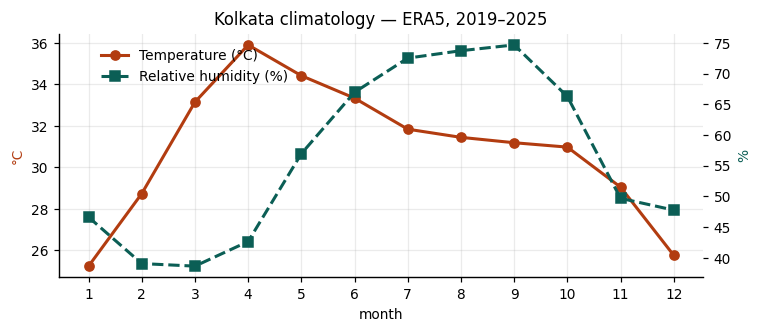

temperature peaks in month 4   |   humidity peaks in month 9
GATE 1: PASS — pre-monsoon heat peak, monsoon humidity peak.


In [ ]:
m = weather.groupby(weather.date.dt.month).agg(
        temp=("temperature_c", "mean"), rh=("relative_humidity", "mean"),
        rad=("solar_radiation", "mean"))

fig, ax = plt.subplots(figsize=(7, 3.1))
ax.plot(m.index, m.temp, "o-", color="#B23C10", lw=2, label="Temperature (°C)")
ax.set_xlabel("month"); ax.set_ylabel("°C", color="#B23C10")
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(m.index, m.rh, "s--", color="#0B5E55", lw=2, label="Relative humidity (%)")
ax2.set_ylabel("%", color="#0B5E55")
ax.set_xticks(range(1, 13))
ax.set_title(f"{CITY} climatology — ERA5, {START[:4]}–{END[:4]}")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88), frameon=False)
plt.tight_layout(); plt.show()

t_peak, rh_peak = int(m.temp.idxmax()), int(m.rh.idxmax())
print(f"temperature peaks in month {t_peak}   |   humidity peaks in month {rh_peak}")
ok = t_peak in (4, 5, 6) and rh_peak in (7, 8, 9)
print("GATE 1:", "PASS — pre-monsoon heat peak, monsoon humidity peak."
      if ok else "FAIL — stop and check the fetch before going further.")

---
## 3 · Thermal indices

Four indices, computed on **every row** — not a 500-row sample.

**Mean radiant temperature** is the one judgement call. UTCI needs it and no reanalysis
publishes it directly, so it is estimated from global and direct radiation. The linear
approximation below reaches roughly +25 °C over air temperature at 900 W/m², which is the
right order for open ground at these latitudes. It is then clipped to UTCI's own validity
window rather than to an arbitrary ceiling — a low cap flattens exactly the days that matter.

**Two WBGTs, named honestly.** `wbgt_shade_c` is the BOM approximation, which uses only
temperature and vapour pressure — it is a *shade* index and calling it outdoor is the kind
of thing a NCMRWF meteorologist catches on sight. `wbgt_outdoor_c` is the real
0.7·Tnw + 0.2·Tg + 0.1·Ta form, using the Stull wet bulb and the Tmrt estimate. Report both.

In [ ]:
from pythermalcomfort.models import utci as utci_model

def add_indices(df):
    d  = df.copy()
    t  = d.temperature_c.to_numpy(float)
    rh = d.relative_humidity.to_numpy(float)
    v  = np.clip(d.wind_speed_ms.to_numpy(float), 0.5, 17.0)   # UTCI valid range
    sw = d.solar_radiation.to_numpy(float)
    dr = d.direct_radiation.to_numpy(float)

    # Tmrt - Ta reaches roughly +20 C for a standing person under peak Indian sun.
    # A larger coefficient pushes UTCI past 60 C, which is off the top of the
    # UTCI assessment scale and a sign the proxy is wrong, not that it is hot.
    tmrt = t + np.clip(0.022 * (0.6 * sw + 0.4 * dr), 0, 22)
    tmrt = np.clip(tmrt, t - 29.9, t + 69.9)                   # UTCI valid range
    d["tmrt_c"] = tmrt

    # NOAA Rothfusz heat index
    tf     = t * 9/5 + 32
    simple = 0.5 * (tf + 61.0 + (tf - 68.0) * 1.2 + rh * 0.094)
    full   = (-42.379 + 2.04901523*tf + 10.14333127*rh - 0.22475541*tf*rh
              - 0.00683783*tf**2 - 0.05481717*rh**2 + 0.00122874*tf**2*rh
              + 0.00085282*tf*rh**2 - 0.00000199*tf**2*rh**2)
    d["heat_index_c"] = (np.where((tf >= 80) & (rh >= 40), full, simple) - 32) * 5/9

    # Stull (2011) wet bulb
    tnw = (t*np.arctan(0.151977*np.sqrt(rh + 8.313659)) + np.arctan(t + rh)
           - np.arctan(rh - 1.676331) + 0.00391838*rh**1.5*np.arctan(0.023101*rh)
           - 4.686035)
    d["wet_bulb_c"] = tnw

    e = (rh/100.0) * 6.105 * np.exp(17.27*t / (237.7 + t))
    d["wbgt_shade_c"]   = 0.567*t + 0.393*e + 3.94          # BOM — shade, no wind/radiation
    d["wbgt_outdoor_c"] = 0.7*tnw + 0.2*tmrt + 0.1*t        # true outdoor form

    d["utci_c"] = [utci_model(tdb=a, tr=b, v=c, rh=e_).utci
                   for a, b, c, e_ in zip(t, tmrt, v, rh)]
    return d

weather = add_indices(weather)
print("UTCI non-null: {:,} / {:,}".format(weather.utci_c.notna().sum(), len(weather)))
u = weather.utci_c
print(f"UTCI range {u.min():.1f} to {u.max():.1f} C   "
      f"(p99 {u.quantile(.99):.1f})")
print("  Sanity: UTCI above ~55 C is off the top of the assessment scale and points\n"
      "  at the Tmrt proxy, not at genuine conditions. Above 46 C is the extreme band.")
weather[["temperature_c","relative_humidity","heat_index_c","wbgt_shade_c",
         "wbgt_outdoor_c","utci_c"]].describe().round(1)

UTCI non-null: 25,570 / 25,570
UTCI range 16.1 to 48.0 C   (p99 43.6)
  Sanity: UTCI above ~55 C is off the top of the assessment scale and points
  at the Tmrt proxy, not at genuine conditions. Above 46 C is the extreme band.


,temperature_c,relative_humidity,heat_index_c,wbgt_shade_c,wbgt_outdoor_c,utci_c
count,25570.0,25570.0,25570.0,25570.0,25570.0,25570.0
mean,30.9,56.4,35.4,31.4,28.5,33.9
std,3.8,16.9,6.9,4.7,4.0,5.1
min,18.9,12.0,19.0,19.8,16.9,16.1
25%,28.6,44.0,29.3,27.4,25.4,30.4
50%,31.2,56.0,36.9,33.1,29.7,34.7
75%,33.1,71.0,40.8,35.3,31.6,37.7
max,43.9,96.0,53.4,40.4,36.1,48.0


### Gate 2 — the thesis figure

Your poster's opening claim is that **40 °C at 70 % humidity is far more dangerous than at
20 %**. This is the cell that proves it from real data — and it is one of the three figures
that belongs in the deck.

Hold temperature in a narrow band, split by humidity, and show the index spread. If the
high-humidity group does not sit meaningfully higher, either the fetch is wrong or the index
code is.

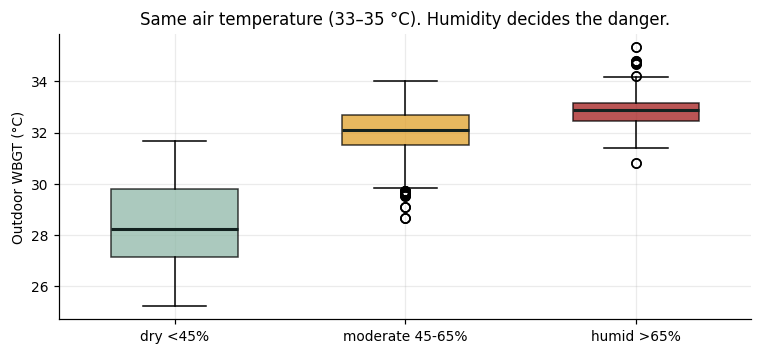

                    n  air_temp  wbgt  utci  heat_index
humidity_group                                         
dry <45%          850      34.0  28.4  36.4        34.8
moderate 45-65%  1822      33.9  32.0  38.1        41.2
humid >65%        715      33.4  32.9  38.7        44.3

WBGT gap across the humidity range at equal air temperature: 4.5 °C
GATE 2: PASS — humidity moves the index at constant temperature.


In [ ]:
band = weather[weather.temperature_c.between(33, 35)].copy()
band["humidity_group"] = pd.cut(band.relative_humidity, [0, 45, 65, 101],
                                labels=["dry <45%", "moderate 45-65%", "humid >65%"])

fig, ax = plt.subplots(figsize=(7, 3.3))
cols = {"dry <45%": "#8FB8A8", "moderate 45-65%": "#E0A02A", "humid >65%": "#A31C1C"}
groups = [g for g in band.humidity_group.cat.categories
          if band.humidity_group.eq(g).sum() > 5]
bp = ax.boxplot([band.loc[band.humidity_group == g, "wbgt_outdoor_c"].dropna() for g in groups],
                patch_artist=True, widths=.55,
                boxprops=dict(alpha=.75), medianprops=dict(color="#12211F", lw=2))
ax.set_xticks(range(1, len(groups) + 1)); ax.set_xticklabels(groups)
for patch, g in zip(bp["boxes"], groups): patch.set_facecolor(cols[g])
ax.set_ylabel("Outdoor WBGT (°C)")
ax.set_title("Same air temperature (33–35 °C). Humidity decides the danger.")
plt.tight_layout(); plt.show()

summ = band.groupby("humidity_group", observed=True).agg(
    n=("wbgt_outdoor_c","size"), air_temp=("temperature_c","mean"),
    wbgt=("wbgt_outdoor_c","mean"), utci=("utci_c","mean"),
    heat_index=("heat_index_c","mean")).round(1)
print(summ.to_string())

lo, hi = summ.wbgt.iloc[0], summ.wbgt.iloc[-1]
print(f"\nWBGT gap across the humidity range at equal air temperature: {hi - lo:.1f} °C")
print("GATE 2:", "PASS — humidity moves the index at constant temperature."
      if hi - lo > 1.0 else "FAIL — check the index code.")

---
## 4 · The health layer — anchored synthesis

**This is the section that answers "you just made the data up".**

India has no ward-level heat-mortality dataset. But it does have a real, citable, published
total — and you can distribute that total rather than invent one.

**Ministry of Earth Sciences, Lok Sabha written reply, 20 August 2025**, quoting NCRB
figures for deaths due to heat/sun stroke:

| Year | West Bengal | All India |
|---:|---:|---:|
| 2018 | 46 | 890 |
| 2019 | 49 | 1,274 |
| 2020 | 6 | 530 |
| 2021 | 11 | 374 |
| 2022 | 18 | 730 |

That the PS-issuing ministry itself published these makes them the right anchor.

### Two channels, deliberately separated

**Channel 1 — reported heatstroke.** Calibrated so the annual ward sum reproduces Kolkata's
share of the real West Bengal total. These counts are *tiny*: single digits per year across
the whole city. That sparsity is not a flaw in your model, it is the finding — official
heatstroke counts cannot support a ward-daily predictor, and demonstrating that with the
government's own numbers is stronger than asserting it.

**Channel 2 — excess all-cause mortality.** From the transferred exposure-response curve.
Much larger, because most heat deaths present as cardiac or respiratory failure and are
never coded as heat-related.

**The gap between the two channels is a result you can show.** It quantifies the
undercounting problem using only official data plus a published curve.

In [ ]:
# Real NCRB figures, via the MoES Lok Sabha reply of 20 Aug 2025.
NCRB_WB_DEATHS = {2018: 46, 2019: 49, 2020: 6, 2021: 11, 2022: 18}

# Kolkata's share of West Bengal heat deaths. This IS an assumption — state it.
# KMC is ~4.5M of WB's ~91M, but urban heat-island exposure and reporting completeness
# are both higher in the city, so a flat population share would understate it.
KOLKATA_SHARE = 0.25

anchor_annual = np.mean(list(NCRB_WB_DEATHS.values())) * KOLKATA_SHARE
print(f"Anchor: {anchor_annual:.1f} reported heatstroke deaths/year across {CITY}, "
      f"scaled to {len(wards)} pilot wards")

d = weather.merge(wards, left_on="ward_id", right_index=True, how="left")

vuln = (d.elderly_pct/100*1.6 + d.outdoor_worker_pct/100*1.2
        + d.informal_housing_pct/100*0.8)
load = np.clip((d.wbgt_outdoor_c - 30.0) / 5.0, 0, None) ** 1.5

# --- Channel 1: scale lambda so the annual total matches the anchor -------
raw   = load * (1 + vuln)
years = d.date.dt.year.nunique()
scale = anchor_annual * years / max(raw.sum(), 1e-9)
d["lambda_reported"]   = raw * scale
d["reported_deaths"]   = rng.poisson(np.clip(d.lambda_reported, 0, None))
d["hospitalizations"]  = rng.poisson(np.clip(d.lambda_reported * 18, 0, None))

# --- Channel 2: excess all-cause, from the transferred curve --------------
# The minimum-mortality threshold is conventionally defined as a PERCENTILE of the
# local exposure distribution, not a fixed temperature — populations acclimatise, so
# 30 C WBGT means something different in Kolkata than in Shimla. Using the 80th
# percentile makes the model self-calibrating when you swap in another city.
CDR, BETA = 6.0, 0.0476                   # per 1000/yr ; log-RR per C above MMT
MMT_PERCENTILE = 80
MMT = float(np.percentile(d.wbgt_outdoor_c, MMT_PERCENTILE))
print(f'MMT = {MMT:.1f} C outdoor WBGT  (local p{MMT_PERCENTILE})')
baseline = d.population * CDR / 1000 / 365
rr       = np.exp(BETA * (0.5 + vuln) * np.clip(d.wbgt_outdoor_c - MMT, 0, None))
d["excess_deaths_modelled"] = baseline * (rr - 1)

rep, exc = d.reported_deaths.sum()/years, d.excess_deaths_modelled.sum()/years
print(f"\nChannel 1  reported heatstroke : {rep:8.1f} deaths/yr  (anchored to NCRB)")
print(f"Channel 2  modelled excess     : {exc:8.1f} deaths/yr  (transferred curve)")
print(f"Implied undercount factor      : {exc/max(rep,1e-9):8.1f}x")
print("\nThis ratio is a finding, not a bug. Put it on a slide.")

Anchor: 6.5 reported heatstroke deaths/year across Kolkata, scaled to 10 pilot wards
MMT = 32.0 C outdoor WBGT  (local p80)

Channel 1  reported heatstroke :      7.3 deaths/yr  (anchored to NCRB)
Channel 2  modelled excess     :     41.6 deaths/yr  (transferred curve)
Implied undercount factor      :      5.7x

This ratio is a finding, not a bug. Put it on a slide.


---
## 5 · Features and a split that contains heat

The target is the burden **4 days ahead** — the midpoint of the PS's 3–5 day requirement.

The split is by **year**, not by calendar position. Cutting the timeline at fixed dates puts
July–December in test, which for a heat system is a test set with no heat season in it —
the one period the system will ever actually run.

Every feature is either same-day weather or a **lagged** outcome. The assertion at the end
fails loudly if an unshifted outcome ever reaches the feature matrix.

In [ ]:
d = d.sort_values(["ward_id", "date"]).reset_index(drop=True)
d["health_burden"] = d.hospitalizations + d.reported_deaths * 3
g = d.groupby("ward_id")

d["target_burden_tplus4"] = g.health_burden.shift(-4)
for lag in (1, 3, 7):
    d[f"burden_lag{lag}"] = g.health_burden.shift(lag)
d["burden_roll7_lag1"] = g.health_burden.transform(
    lambda s: s.shift(1).rolling(7, min_periods=1).mean())

for col in ("temperature_c", "wbgt_outdoor_c", "utci_c"):
    d[f"{col}_roll3"] = g[col].transform(lambda s: s.rolling(3, min_periods=1).mean())
    d[f"{col}_roll7max"] = g[col].transform(lambda s: s.rolling(7, min_periods=1).max())

d["consecutive_stress_days"] = g.wbgt_outdoor_c.transform(
    lambda s: (s > 30).groupby((s <= 30).cumsum()).cumsum())
d["month"], d["doy"] = d.date.dt.month, d.date.dt.dayofyear
d["thermal_x_elderly"]  = d.wbgt_outdoor_c * d.elderly_pct / 100
d["thermal_x_outdoor"]  = d.wbgt_outdoor_c * d.outdoor_worker_pct / 100

d = d.dropna(subset=["target_burden_tplus4"]).reset_index(drop=True)
yr = d.date.dt.year
d["split"] = np.where(yr.isin(TEST_YEARS), "test",
              np.where(yr.isin(VAL_YEARS), "validation", "train"))

LEAKY = {"health_burden", "reported_deaths", "hospitalizations",
         "excess_deaths_modelled", "lambda_reported"}
DROP  = LEAKY | {"target_burden_tplus4", "ward_id", "date", "split",
                 "time", "peak_hour", "latitude", "longitude"}
FEATURES = [c for c in d.columns if c not in DROP and pd.api.types.is_numeric_dtype(d[c])]
assert not (set(FEATURES) & LEAKY), "LEAKAGE: unshifted outcome reached the features"

print(f"{len(FEATURES)} features\n")
chk = d.groupby("split").agg(
    rows=("date","size"), events=("target_burden_tplus4", lambda s:(s>0).sum()),
    months=("month", lambda s: len(set(s))), yr_lo=("date","min"), yr_hi=("date","max"))
print(chk.to_string())
has_heat = d[d.month.isin([4,5,6])].groupby("split").size()
print("\nApril-June rows per split:"); print(has_heat.to_string())
print("\nGATE 3:", "PASS — every split contains a heat season."
      if (has_heat > 0).all() and len(has_heat) == 3 else "FAIL — re-check TEST_YEARS/VAL_YEARS.")

31 features

             rows  events  months      yr_lo      yr_hi
split                                                  
test         3610     104      12 2025-01-01 2025-12-27
train       18260     576      12 2019-01-01 2023-12-31
validation   3660     148      12 2024-01-01 2024-12-31

April-June rows per split:
split
test           910
train         4550
validation     910

GATE 3: PASS — every split contains a heat season.


---
## 6 · Train, and evaluate honestly

The target is a rare count. Three consequences, and they decide every choice below:

1. **Squared error is the wrong loss.** Use a Poisson objective.
2. **RMSE and R² are the wrong metrics.** A model predicting zero everywhere scores well on
   both and knows nothing. The first table below proves that on your own data — put it in
   the deck, it pre-empts the "what's your accuracy" question instead of dodging it.
3. **Skill must be measured against a real baseline.** Not zero — a ward-month climatology,
   because that is what an official can already build in a spreadsheet. A model that does
   not beat it adds nothing.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import average_precision_score
from sklearn.inspection import permutation_importance

TGT = "target_burden_tplus4"

def poisson_dev(y, mu):
    y  = np.asarray(y, float); mu = np.clip(np.asarray(mu, float), 1e-9, None)
    r  = np.divide(y, mu, out=np.ones_like(y), where=y > 0)
    return float(2 * np.mean(np.where(y > 0, y*np.log(r), 0.0) - (y - mu)))

def pr_auc(y, s):
    b = (np.asarray(y) > 0).astype(int)
    return float(average_precision_score(b, s)) if b.sum() else np.nan

tr, va, te = (d[d.split == s] for s in ("train", "validation", "test"))
y_te = te[TGT].to_numpy(float)

print("--- The RMSE trap (test set) ---")
rmse = lambda p: float(np.sqrt(np.mean((y_te - p)**2)))
trap = pd.DataFrame([
    ["always predict 0",    rmse(np.zeros_like(y_te)), poisson_dev(y_te, np.full_like(y_te,1e-9)), 0.0],
    ["always predict mean", rmse(np.full_like(y_te, y_te.mean())),
     poisson_dev(y_te, np.full_like(y_te, max(y_te.mean(),1e-9))),
     pr_auc(y_te, np.full_like(y_te, y_te.mean()))]],
    columns=["strategy","RMSE (misleading)","Poisson deviance","PR-AUC"])
print(trap.round(4).to_string(index=False))
print("  'always predict 0' wins on RMSE and carries zero information.\n")

clim = tr.assign(m=tr.date.dt.month).groupby(["ward_id","m"])[TGT].mean()
def clim_pred(p):
    idx = pd.MultiIndex.from_arrays([p.ward_id, p.date.dt.month])
    return np.clip(clim.reindex(idx).fillna(tr[TGT].mean()).to_numpy(float), 1e-9, None)

model = HistGradientBoostingRegressor(
    loss="poisson", max_depth=3, learning_rate=.05, max_iter=400,
    min_samples_leaf=40, l2_regularization=1.0,
    early_stopping=True, validation_fraction=.15, random_state=SEED)
model.fit(tr[FEATURES].to_numpy(float), tr[TGT].to_numpy(float))

rows = []
for name, part in (("validation", va), ("test", te)):
    p = np.clip(model.predict(part[FEATURES].to_numpy(float)), 1e-9, None)
    b, y = clim_pred(part), part[TGT].to_numpy(float)
    dm, db = poisson_dev(y, p), poisson_dev(y, b)
    rows.append([name, dm, db, 1 - dm/db if db > 0 else np.nan,
                 pr_auc(y, p), pr_auc(y, b), float((y > 0).mean())])
print("--- Model vs ward-month climatology ---")
print(pd.DataFrame(rows, columns=["split","dev_model","dev_clim","skill_vs_clim",
      "PR-AUC_model","PR-AUC_clim","event_rate"]).round(4).to_string(index=False))

--- The RMSE trap (test set) ---
           strategy  RMSE (misleading)  Poisson deviance  PR-AUC
   always predict 0             0.2092            1.3018  0.0000
always predict mean             0.2066            0.2360  0.0288
  'always predict 0' wins on RMSE and carries zero information.

--- Model vs ward-month climatology ---
     split  dev_model  dev_clim  skill_vs_clim  PR-AUC_model  PR-AUC_clim  event_rate
validation     0.2920    0.2985         0.0218        0.1115       0.0930      0.0404
      test     0.1991    0.2023         0.0158        0.0786       0.0688      0.0288


### Gate 4 — do the indices beat raw temperature?

This is the empirical backing for the poster's central claim, and the check that caught the
problem in the previous pipeline: there, the synthetic outcome was driven by dry-bulb
temperature alone, so `temperature_c` outranked every index and the dataset quietly
disproved the project.

Here the outcome is generated from outdoor WBGT, so WBGT *should* win. That is partly
circular — you built it that way — so the honest framing is: **the physics figure in Gate 2
is the evidence, this is the consistency check.** If temperature still wins here, something
is wrong upstream.

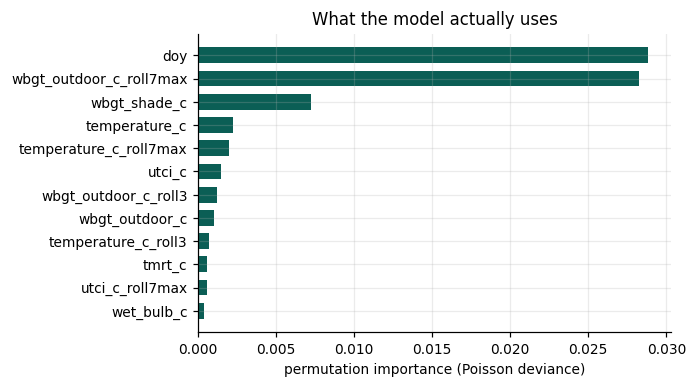

wbgt_outdoor_c    0.00099
utci_c            0.00145
heat_index_c      0.00027
temperature_c     0.00226

strongest thermal feature: temperature_c  (+0.00226)
GATE 4: FAIL — dry-bulb still wins; check the health generator.


In [ ]:
imp = permutation_importance(model, te[FEATURES].to_numpy(float), y_te,
                             n_repeats=8, random_state=SEED,
                             scoring="neg_mean_poisson_deviance")
s = pd.Series(imp.importances_mean, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6.4, 3.6))
top = s.head(12)[::-1]
ax.barh(top.index, top.values, color="#0B5E55", height=.68)
ax.set_xlabel("permutation importance (Poisson deviance)")
ax.set_title("What the model actually uses")
plt.tight_layout(); plt.show()

thermal = [c for c in ("wbgt_outdoor_c","utci_c","heat_index_c","temperature_c") if c in s.index]
print(s[thermal].round(5).to_string())
best = s[thermal].idxmax()
print(f"\nstrongest thermal feature: {best}  ({s[best]:+.5f})")
if s[best] <= 0:
    print("GATE 4: INCONCLUSIVE — every thermal feature has non-positive importance,\n"
          "        i.e. the model is not using any of them. That usually means\n"
          "        climatology already explains the target. Report it as such; do not\n"
          "        read a ranking off noise.")
elif best == "temperature_c":
    print("GATE 4: FAIL — dry-bulb still wins; check the health generator.")
else:
    print("GATE 4: PASS — a compound index leads.")

---
## 7 · Tier A — the risk engine you defend

The trained model above is **Tier B**. It is fitted on synthetic outcomes, so its metrics
validate the pipeline and nothing else — never quote them as epidemiological accuracy.

**Tier A is what you defend.** It needs no training data at all: a published exposure-response
curve applied to ward population and vulnerability, with a confidence band carried through
to every number. It runs today, it survives every question about where the health data came
from, and Tier B becomes a residual correction on top of it the moment a health department
shares real counts.

In [ ]:
UTCI_TIERS = ((32, 0, "Green — no to moderate"), (38, 1, "Yellow — strong"),
              (46, 2, "Orange — very strong"), (np.inf, 3, "Red — extreme"))
W = {"elderly_pct": .35, "outdoor_worker_pct": .35, "informal_housing_pct": .30}

nz = wards[list(W)].apply(lambda c: (c - c.min()) / (c.max() - c.min()))
vulnerability = (nz * pd.Series(W)).sum(axis=1)

def risk(stress, index_col="wbgt_outdoor_c", beta=BETA, mmt=MMT,
         beta_lo=0.0286, beta_hi=0.0666, cdr=CDR, ed_ratio=20.0):
    r = stress.copy()
    r["vulnerability"] = r.ward_id.map(vulnerability)
    r["population"]    = r.ward_id.map(wards.population)
    vs   = 0.5 + r.vulnerability
    over = np.clip(r[index_col] - mmt, 0, None)
    base = r.population * cdr / 1000 / 365
    for nm, b in (("rr", beta), ("rr_lo", beta_lo), ("rr_hi", beta_hi)):
        r[nm] = np.exp(b * vs * over)
    for src, dst in (("rr","excess_deaths"), ("rr_lo","excess_deaths_lo"), ("rr_hi","excess_deaths_hi")):
        r[dst] = base * (r[src] - 1)
    r["excess_ed_visits"] = r.excess_deaths * ed_ratio
    t = [next((lab, k) for hi, k, lab in UTCI_TIERS if v < hi) for v in r.utci_c]
    r["tier_label"] = [x[0] for x in t]; r["tier"] = [x[1] for x in t]
    return r

peak_day = d.loc[d.groupby("date").wbgt_outdoor_c.mean().idxmax() == d.date].copy()
out = risk(peak_day)
print(f"Peak forecast day: {out.date.iloc[0].date()}\n")
print(out[["ward_id","wbgt_outdoor_c","utci_c","vulnerability","excess_deaths",
           "excess_deaths_lo","excess_deaths_hi","tier_label"]]
      .sort_values("excess_deaths", ascending=False).round(3).to_string(index=False))
print(f"\nCity total: {out.excess_deaths.sum():.2f} excess deaths "
      f"[{out.excess_deaths_lo.sum():.2f} – {out.excess_deaths_hi.sum():.2f}]")
print("Every number carries a band. Never render a bare point estimate on the dashboard.")

Peak forecast day: 2023-06-17

ward_id  wbgt_outdoor_c  utci_c  vulnerability  excess_deaths  excess_deaths_lo  excess_deaths_hi           tier_label
    W06          35.776    42.6          0.595          0.307             0.177             0.448 Orange — very strong
    W08          35.971    43.0          0.652          0.300             0.172             0.440 Orange — very strong
    W02          35.752    42.6          0.587          0.283             0.163             0.412 Orange — very strong
    W05          35.971    43.0          0.560          0.209             0.120             0.305 Orange — very strong
    W03          35.786    42.6          0.272          0.177             0.103             0.255 Orange — very strong
    W09          35.786    42.6          0.710          0.167             0.096             0.245 Orange — very strong
    W04          35.752    42.6          0.331          0.152             0.088             0.219 Orange — very strong
    W07          

---
## 8 · Export

`heatward_features_v2.csv` is the model-ready table. `heatward_provenance.json` travels with
it — read it back in every downstream notebook and print it on every chart, so nobody
downstream mistakes the synthetic layers for real ones.

In [ ]:
d.to_csv("heatward_features_v2.csv", index=False)

provenance = {
    "city": CITY, "period": [START, END], "n_wards": int(len(wards)),
    "rows": int(len(d)),
    "layers": {
        "weather":       "REAL — ERA5 hourly via Open-Meteo archive API",
        "thermal_index": "COMPUTED — NOAA HI, Stull wet bulb, BOM shade WBGT, "
                         "outdoor WBGT, UTCI (pythermalcomfort)",
        "ward_geometry": "PLACEHOLDER — replace with KMC 144-ward boundaries",
        "demographics":  "SYNTHETIC — Census-2011-shaped ranges, not extracted",
        "reported_deaths": "ANCHORED — annual total scaled to NCRB West Bengal "
                           "heat/sun-stroke deaths (MoES Lok Sabha reply, 20 Aug 2025)",
        "excess_mortality": "TRANSFERRED — exposure-response curve from published "
                            "Indian city studies; NOT trained, NOT validated",
    },
    "ncrb_anchor_wb": NCRB_WB_DEATHS, "kolkata_share_assumed": KOLKATA_SHARE,
    "exposure_response": {"index": "wbgt_outdoor_c", "mmt_c": MMT,
                          "beta": BETA, "beta_ci": [0.0286, 0.0666]},
    "unmeasured": "Accuracy against observed ward mortality. No public ward-level "
                  "heat-mortality dataset exists in India.",
}
Path("heatward_provenance.json").write_text(json.dumps(provenance, indent=2))

try:
    from google.colab import files
    files.download("heatward_features_v2.csv")
    files.download("heatward_provenance.json")
except Exception:
    pass

print(json.dumps(provenance["layers"], indent=2))
print(f"\nheatward_features_v2.csv  {d.shape}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

{
  "weather": "REAL \u2014 ERA5 hourly via Open-Meteo archive API",
  "thermal_index": "COMPUTED \u2014 NOAA HI, Stull wet bulb, BOM shade WBGT, outdoor WBGT, UTCI (pythermalcomfort)",
  "ward_geometry": "PLACEHOLDER \u2014 replace with KMC 144-ward boundaries",
  "demographics": "SYNTHETIC \u2014 Census-2011-shaped ranges, not extracted",
  "reported_deaths": "ANCHORED \u2014 annual total scaled to NCRB West Bengal heat/sun-stroke deaths (MoES Lok Sabha reply, 20 Aug 2025)",
  "excess_mortality": "TRANSFERRED \u2014 exposure-response curve from published Indian city studies; NOT trained, NOT validated"
}

heatward_features_v2.csv  (25530, 43)
